# Working with shapefiles

This notebook shows some lower-level functionality in `flopy` for working with shapefiles
including:
* `utils.geometry` classes for writing shapefiles of model input/output. For example, quickly writing a shapefile of model cells with errors identified by the checker
* examples of how the `Point` and `LineString` classes can be used to quickly plot pathlines and endpoints from MODPATH (these are also used by the `PathlineFile` and `EndpointFile` classes to write shapefiles of this output)

In [15]:
import os
import shutil
import sys
import warnings
from pathlib import Path
from tempfile import TemporaryDirectory

import geopandas as gpd
import git
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pooch

import flopy
from flopy.utils import geometry
from flopy.utils.geometry import LineString, Point, Polygon
from flopy.utils.modpathfile import EndpointFile, PathlineFile

warnings.simplefilter("ignore", UserWarning)
print(sys.version)
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
numpy version: 2.4.4
matplotlib version: 3.10.9
flopy version: 3.10.0


### write a numpy record array to a shapefile
in this case, we want to visualize output from the checker
first make a toy model

In [16]:
temp_dir = TemporaryDirectory()
workspace = temp_dir.name

# Check if we are in the repository and define the data path.

try:
    root = Path(git.Repo(".", search_parent_directories=True).working_dir)
except:
    root = None

data_path = root / "examples" / "data" if root else Path.cwd()

m = flopy.modflow.Modflow("toy_model", model_ws=workspace)
botm = np.zeros((2, 10, 10))
botm[0, :, :] = 1.5
botm[1, 5, 5] = 4  # negative layer thickness!
botm[1, 6, 6] = 4
dis = flopy.modflow.ModflowDis(
    nrow=10, ncol=10, nlay=2, delr=100, delc=100, top=3, botm=botm, model=m
)

### set coordinate information

In [17]:
grid = m.modelgrid
grid.set_coord_info(xoff=600000, yoff=5170000, crs="EPSG:26715", angrot=45)

In [18]:
chk = dis.check()
chk.summary_array


DIS PACKAGE DATA VALIDATION:
  2 Errors:
    2 instances of zero or negative thickness

  Checks that passed:
    thin cells (less than checker threshold of 1.0)
    nan values in top array
    nan values in bottom array



rec.array([(np.str_('Error'), np.str_('DIS'), 1, 5, 5, -2.5, np.str_('zero or negative thickness')),
           (np.str_('Error'), np.str_('DIS'), 1, 6, 6, -2.5, np.str_('zero or negative thickness'))],
          dtype=[('type', 'O'), ('package', 'O'), ('k', '<i8'), ('i', '<i8'), ('j', '<i8'), ('value', '<f8'), ('desc', 'O')])

### make geometry objects for the cells with errors
*  geometry objects allow the shapefile writer to be simpler and agnostic about the kind of geometry

In [19]:
get_vertices = (
    m.modelgrid.get_cell_vertices
)  # function to get the referenced vertices for a model cell
geoms = [Polygon(get_vertices(i, j)) for i, j in chk.summary_array[["i", "j"]]]

In [20]:
geoms[0].type

'Polygon'

In [21]:
geoms[0].exterior

((np.float64(600000.0), np.float64(5170707.106781187)),
 (np.float64(600070.7106781186), np.float64(5170777.817459305)),
 (np.float64(600141.4213562373), np.float64(5170707.106781187)),
 (np.float64(600070.7106781186), np.float64(5170636.396103068)))

In [22]:
geoms[0].bounds

(np.float64(600000.0),
 np.float64(5170636.396103068),
 np.float64(600141.4213562373),
 np.float64(5170777.817459305))

could not plot polygon feature


<Axes: >

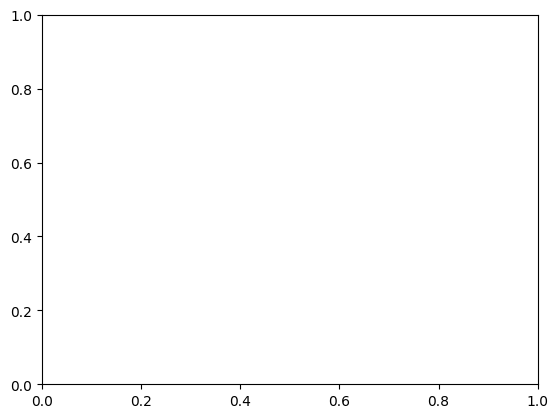

In [23]:
geoms[0].plot()  # this feature requires descartes

### create a GeoDataFrame and write it to shapefile
* the projection (.prj) file can be written using an epsg code or crs

In [24]:
from pathlib import Path

gdf = gpd.GeoDataFrame(data=chk.summary_array, geometry=geoms)
gdf.to_file(os.path.join(workspace, "test.shp"))


### read it back in
* We can use geopandas to read it back into memory

In [25]:
gdf = gpd.read_file(os.path.join(workspace, "test.shp"))
gdf.head()

,type,package,k,i,j,value,desc,geometry
0,Error,DIS,1,5,5,-2.5,zero or negative thickness,"POLYGON ((600000 5170707.107, 600070.711 51707..."
1,Error,DIS,1,6,6,-2.5,zero or negative thickness,"POLYGON ((600141.421 5170707.107, 600212.132 5..."


<Axes: >

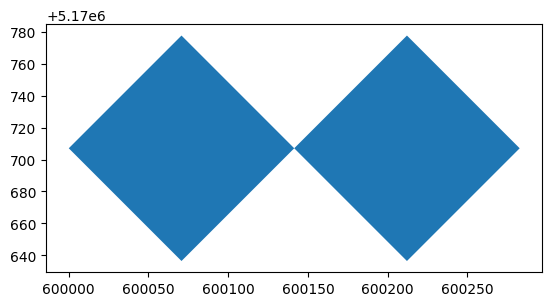

In [26]:
gdf.geometry.plot()
# -

## Other geometry types

### Linestring
* create geometry objects for pathlines from a MODPATH simulation
* plot the paths using the built in plotting method

In [29]:
fname = "EXAMPLE-3.pathline"
pthfile = pooch.retrieve(
    url=f"https://github.com/modflowpy/flopy/raw/develop/examples/data/mp6/{fname}",
    fname=fname,
    path=data_path / "mp6",
    # path = "/home/jorge/Documents/github/flopy_documents/linux/mf6",
    known_hash=None,
)
pthfile = PathlineFile(pthfile)
pthdata = pthfile._data.view(np.recarray)

In [30]:
length_mult = 1.0  # multiplier to convert coordinates from model to real world
rot = 0  # grid rotation

particles = np.unique(pthdata.particleid)
geoms = []
for pid in particles:
    ra = pthdata[pthdata.particleid == pid]

    x, y = geometry.rotate(
        ra.x * length_mult, ra.y * length_mult, grid.xoffset, grid.yoffset, rot
    )
    z = ra.z
    geoms.append(LineString(list(zip(x, y, z))))

In [31]:
geoms[0]

<Axes: >

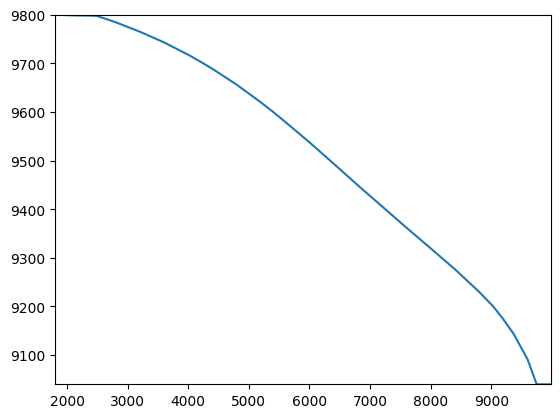

In [32]:
geoms[0].plot()

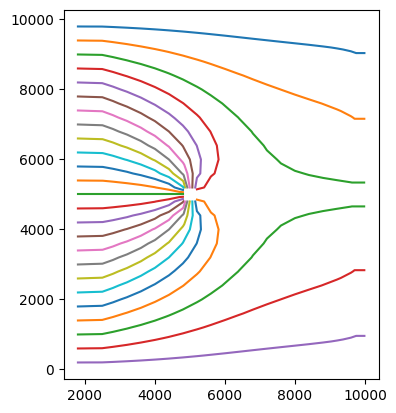

In [33]:
fig, ax = plt.subplots()
for g in geoms:
    g.plot(ax=ax)
ax.autoscale()
ax.set_aspect(1)

## Points

In [34]:
fname = "EXAMPLE-3.endpoint"
eptfile = pooch.retrieve(
    url=f"https://github.com/modflowpy/flopy/raw/develop/examples/data/mp6/{fname}",
    fname=fname,
    path=data_path / "mp6",
    known_hash=None,
)
eptfile = EndpointFile(eptfile)
eptdata = eptfile.get_alldata()

In [35]:
x, y = geometry.rotate(
    eptdata["x0"] * length_mult,
    eptdata["y0"] * length_mult,
    grid.xoffset,
    grid.yoffset,
    rot,
)
z = eptdata["z0"]

geoms = [Point(x[i], y[i], z[i]) for i in range(len(eptdata))]

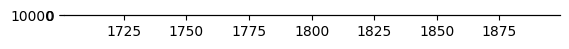

In [36]:
fig, ax = plt.subplots()
for g in geoms:
    g.plot(ax=ax)
ax.autoscale()
ax.set_aspect(2e-6)

In [37]:
try:
    # ignore PermissionError on Windows
    temp_dir.cleanup()
except:
    pass